<a href="https://colab.research.google.com/github/phlippa/LIP_Internships26_SNDATLAS/blob/main/to_df.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
!pip install uproot
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak

In [46]:
# Get the data
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/LIP_internships26_SNDATLAS/"

!mkdir -p "$data_path"
!wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/epos_lhc_14TeV_v2.root -P "$data_path"
!wget -N https://cristova.web.cern.ch/cristova/share/LIP_Internships/pwgevents-PYTHIA-filtered_v2.root -P "$data_path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--2026-07-14 14:46:57--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/epos_lhc_14TeV_v2.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 188.184.111.229, 188.184.96.45, 137.138.55.232, ...
Connecting to cristova.web.cern.ch (cristova.web.cern.ch)|188.184.111.229|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218362057 (208M)
Saving to: ‘/content/drive/MyDrive/LIP_internships26_SNDATLAS/epos_lhc_14TeV_v2.root’

epos_lhc_14TeV_v2.r 100%[===================>] 208.25M  15.1MB/s    in 15s     

2026-07-14 14:47:12 (14.3 MB/s) - ‘/content/drive/MyDrive/LIP_internships26_SNDATLAS/epos_lhc_14TeV_v2.root’ saved [218362057/218362057]

--2026-07-14 14:47:12--  https://cristova.web.cern.ch/cristova/share/LIP_Internships/pwgevents-PYTHIA-filtered_v2.root
Resolving cristova.web.cern.ch (cristova.web.cern.ch)... 188.184

In [47]:
signal = uproot.open(data_path+"/pwgevents-PYTHIA-filtered_v2.root:Events")
background = uproot.open(data_path+"/epos_lhc_14TeV_v2.root:Events")
signal.show()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
npdg                 | int32_t                  | AsDtype('>i4')
pdg                  | int64_t[]                | AsJagged(AsDtype('>i8'))
ncharge              | int32_t                  | AsDtype('>i4')
charge               | double[]                 | AsJagged(AsDtype('>f8'))
npx                  | int32_t                  | AsDtype('>i4')
px                   | double[]                 | AsJagged(AsDtype('>f8'))
npy                  | int32_t                  | AsDtype('>i4')
py                   | double[]                 | AsJagged(AsDtype('>f8'))
npz                  | int32_t                  | AsDtype('>i4')
pz                   | double[]                 | AsJagged(AsDtype('>f8'))
neta                 | int32_t                  | AsDtype('>i4')
eta                  | double[]                 | AsJagged(AsDtype('>f8')

In [48]:
def makeDataFrame(root_tree):
  this_df = pd.DataFrame()
  this_df["n"] = 0.0

  n = 0
  for i_event, event in enumerate(root_tree["npt"].array()):
    if i_event % 10000 == 0:
      print(f"Processing event {i_event}")
    this_df._set_value(index=n, col="n", value = event)
    n+=1

  for key in root_tree.keys():
    print(f"Processing {key}")
    if key.startswith("n") or key.startswith("m") or key.startswith("charge") or key.startswith("pdg"): continue

    for i in range(1, 4):
      this_df[key + str(i)] = 0.0
    n = 0
    for event in root_tree[key].array():
      for j in range(0, min(3,len(event))):
        this_df._set_value(index=n, col=key + str(j+1), value = event[j])
      n += 1
  #this_df._set_value(index=n, col=key + str(i), value = event[j])

  #this_df["mpt"] = root_tree["mpt"].array()
  this_df["nu_eta"] = root_tree["nu_eta"].array()
  this_df["nu_phi"] = root_tree["nu_phi"].array()
  this_df["nu_E"] = root_tree["nu_E"].array()


  this_df["dphi2"] = this_df["phi2"] - this_df["phi1"]
  this_df["dphi3"] = this_df["phi3"] - this_df["phi1"]
  this_df["p1"] = np.sqrt(this_df["px1"]**2 + this_df["py1"]**2 + this_df["pz1"]**2)
  this_df["p2"] = np.sqrt(this_df["px2"]**2 + this_df["py2"]**2 + this_df["pz2"]**2)
  this_df["p3"] = np.sqrt(this_df["px3"]**2 + this_df["py3"]**2 + this_df["pz3"]**2)
  this_df["nu_dphi1"] = this_df["phi1"] - this_df["nu_phi"]
  this_df["nu_dphi2"] = this_df["phi2"] - this_df["nu_phi"]
  this_df["nu_dphi3"] = this_df["phi3"] - this_df["nu_phi"]


  this_df = this_df.fillna(0)
  this_df.head()
  return this_df

In [49]:
signal_df = makeDataFrame(signal)
background_df = makeDataFrame(background)

Processing event 0
Processing event 10000
Processing event 20000
Processing event 30000
Processing event 40000
Processing event 50000
Processing npdg
Processing pdg
Processing ncharge
Processing charge
Processing npx
Processing px
Processing npy
Processing py
Processing npz
Processing pz
Processing neta
Processing eta
Processing nphi
Processing phi
Processing npt
Processing pt
Processing nnu_eta
Processing nu_eta
Processing nnu_phi
Processing nu_phi
Processing nnu_E
Processing nu_E
Processing event 0
Processing event 10000
Processing event 20000
Processing event 30000
Processing event 40000
Processing npdg
Processing pdg
Processing ncharge
Processing charge
Processing npx
Processing px
Processing npy
Processing py
Processing npz
Processing pz
Processing neta
Processing eta
Processing nphi
Processing phi
Processing npt
Processing pt
Processing nnu_eta
Processing nu_eta
Processing nnu_phi
Processing nu_phi
Processing nnu_E
Processing nu_E


In [50]:
signal_df.tail()
background_df.tail()

,n,px1,px2,px3,py1,py2,py3,pz1,pz2,pz3,...,nu_phi,nu_E,dphi2,dphi3,p1,p2,p3,nu_dphi1,nu_dphi2,nu_dphi3
49995,228.0,-1.039783,-1.197088,-1.869239,2.396003,-2.181561,-1.545823,12.136765,30.362288,-0.983759,...,-1.510730,285.957684,-4.052900,-4.430852,12.414630,30.464089,2.617519,3.490967,-0.561934,-0.939886
49996,457.0,-4.284599,0.651009,0.222974,-0.358028,3.899701,-3.710017,0.189481,-2.097395,3.870364,...,1.445480,768.933073,4.463608,1.547457,4.303705,4.475550,5.365972,-4.503704,-0.040096,-2.956248
49997,70.0,1.597966,1.442739,0.037521,-0.345563,0.026798,1.160540,1.298135,0.901560,-1.025383,...,0.386482,242.420090,0.231545,1.751449,2.087598,1.701477,1.549087,-0.599455,-0.367910,1.151995
49998,340.0,-5.727715,5.428311,5.508620,2.916284,-1.128101,-0.437454,3.137756,13.456615,12.163089,...,1.033291,109.152307,-2.875551,-2.749896,7.152408,14.554026,13.359528,1.637358,-1.238193,-1.112538
49999,43.0,-0.317762,-0.662435,-0.021459,-1.232240,0.998562,1.014786,-0.212035,-0.406310,0.446097,...,0.224861,360.050928,3.979698,3.415111,1.290095,1.265320,1.108717,-2.048033,1.931665,1.367079


In [51]:
import numpy as np

def apply_pt_eta_cuts(df, pt_min=0.250, eta_max=4, n_particles=3):
    """
    Zeroes out (px, py, pz) for particles failing pt or eta cuts.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns px{i}, py{i}, pz{i} for i in 1..n_particles.
        Momenta assumed to be in GeV.
    pt_min : float
        Minimum transverse momentum in GeV (default 0.250 GeV = 250 MeV).
    eta_max : float
        Maximum |eta| allowed (default 4).
    n_particles : int
        Number of particles per row (default 3).

    Returns
    -------
    pd.DataFrame
        A copy of df with px/py/pz set to 0 for particles failing either cut.
    """
    df = df.copy()

    for i in range(1, n_particles + 1):
        px, py, pz = f'px{i}', f'py{i}', f'pz{i}'

        # --- Transverse momentum cut ---
        pt = np.sqrt(df[px]**2 + df[py]**2)
        low_pt_mask = pt < pt_min
        df.loc[low_pt_mask, [px, py, pz]] = 0

        # --- Recompute pt after zeroing, then eta cut ---
        pt = np.sqrt(df[px]**2 + df[py]**2)
        with np.errstate(divide='ignore', invalid='ignore'):
            eta = np.arcsinh(df[pz] / pt)
        eta = eta.fillna(np.inf)  # pt=0 particles fail the eta cut too

        high_eta_mask = eta.abs() >= eta_max
        df.loc[high_eta_mask, [px, py, pz]] = 0

    return df

In [52]:
signal_df = apply_pt_eta_cuts(signal_df)
background_df = apply_pt_eta_cuts(background_df)

In [ ]:
signal_df["target"] = 1.
background_df["target"] = 0.
signal_df = signal_df.drop(columns=["phi1", "phi2", "phi3"])
background_df = background_df.drop(columns=["phi1", "phi2", "phi3"])


In [55]:
signal_df.to_csv(data_path + "signal_v2_eta_E.csv", index=False)
background_df.to_csv(data_path + "background_v2_eta_E.csv", index=False)

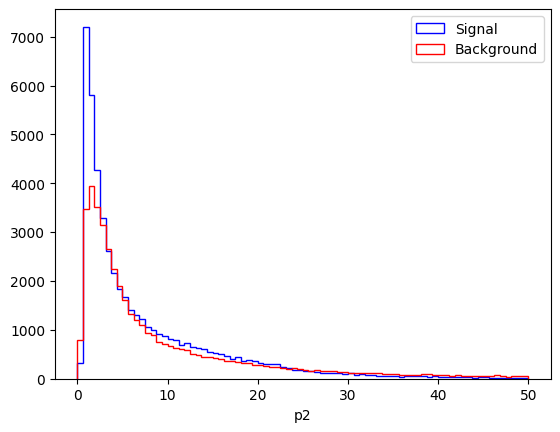

In [56]:

plt.figure()

plt.hist(
    signal_df["p2"][signal_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="b",
    label="Signal"
)

plt.hist(
    background_df["p2"][background_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="r",
    label="Background"
)

plt.xlabel("p2")
plt.legend()
plt.show()


